## Spatial Data Science (GIS6307/GEO4930)

---

# Lab 4: Vector and Raster Model

In this lab, you will create choropleth map from a GeoDataFrame. You will compare the maps using different classification methods.

### `Due on Monday 2/14. Submit Jupyter Notebook in Canvas`

<br>
Instructor: Yi Qiang (qiangy@usf.edu)<br>
Teaching Assistant: Jinwen Xu (jinwenxu@usf.edu)


---

## 1. Install libpysal

[libpysal](https://pysal.org/libpysal/) is an library that includes many useful spatial datasets and analytical tools.

1. Please open Anaconda Prompt, and use the command `conda activate geo` to activate the "geo" environment that you created in the previous lab. 

2. Install libpysal using the following command:

    `conda install -c conda-forge libpysal`
    
3. Run the following code to import libpysal and other needed packages.

In [45]:
import mapclassify as mc
import libpysal
import geopandas as gpd
import matplotlib.pyplot as plt

# enable inline plotting (may not be neccesary in jupyter notebook)
%matplotlib inline 

#set default plotting size
plt.rcParams['figure.figsize'] = [10, 10]

## 2. Read and Explore the Dataset

Read the shapefile `south.shp` into a GeoDataFrame `gdf`

In [39]:
# Read south.shp into a GeoDataFrame
gdf = gpd.read_file('other/south.shp')

# Preview the GeoDataFrame
gdf.head()

,NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,FIPS,STFIPS,COFIPS,FIPSNO,SOUTH,HR60,...,BLK90,GI59,GI69,GI79,GI89,FH60,FH70,FH80,FH90,geometry
0,Hancock,West Virginia,54,029,54029,54,29,54029,1,1.682864,...,2.557262,0.223645,0.295377,0.332251,0.363934,9.981297,7.8,9.785797,12.604552,"POLYGON ((-80.62805 40.39816, -80.60204 40.480..."
1,Brooke,West Virginia,54,009,54009,54,9,54009,1,4.607233,...,0.748370,0.220407,0.318453,0.314165,0.350569,10.929337,8.0,10.214990,11.242293,"POLYGON ((-80.52625 40.16245, -80.58760 40.175..."
2,Ohio,West Virginia,54,069,54069,54,69,54069,1,0.974132,...,3.310334,0.272398,0.358454,0.376963,0.390534,15.621643,12.9,14.716681,17.574021,"POLYGON ((-80.52517 40.02275, -80.73843 40.035..."
3,Marshall,West Virginia,54,051,54051,54,51,54051,1,0.876248,...,0.546097,0.227647,0.319580,0.320953,0.377346,11.962834,8.8,8.803253,13.564159,"POLYGON ((-80.52447 39.72113, -80.83248 39.718..."
4,New Castle,Delaware,10,003,10003,10,3,10003,1,4.228385,...,16.480294,0.256106,0.329678,0.365830,0.332703,12.035714,10.7,15.169480,16.380903,"POLYGON ((-75.77270 39.38301, -75.79144 39.723..."


The `gdf` consists of a number of columns in special codings. You can print all columns in gdf:

In [41]:
df.columns

Index(['OBJECTID', 'AREA', 'PERIMETER', 'COMAREA_', 'COMAREA_ID', 'AREA_NUMBE',
       'COMMUNITY', 'AREA_NUM_1', 'SHAPE_AREA', 'SHAPE_LEN', 'AREANO',
       'geometry'],
      dtype='object')

The meanings of the columns are as follows:


| Variable | Description |
| :---        | :---       |
|NAME|	county name|
|STATE_NAME|	state name|
|STATE_FIPS|	state fips code (character)|
|CNTY_FIPS|	county fips code (character)|
|FIPS|	combined state and county fips code (character)|
|STFIPS|	state fips code (numeric)|
|COFIPS|	county fips code (numeric)|
|FIPSNO|	fips code as numeric variable|
|SOUTH|	dummy variable for Southern counties (South = 1)|
|HR**|	homicide rate per 100,000 (1960, 1970, 1980, 1990)|
|HC**|	homicide count, three year average centered on 1960, 1970, 1980, 1990|
|PO**|	county population, 1960, 1970, 1980, 1990|
|RD**|	resource deprivation 1960, 1970, 1980, 1990 (principal component, see Codebook for details)|
|PS**|	population structure 1960, 1970, 1980, 1990 (principal component, see Codebook for details)|
|UE**|	unemployment rate 1960, 1970, 1980, 1990|
|DV**|	divorce rate 1960, 1970, 1980, 1990 (% males over 14 divorced)|
|MA**|	median age 1960, 1970, 1980, 1990|
|POL**|	log of population 1960, 1970, 1980, 1990|
|DNL**|	log of population density 1960, 1970, 1980, 1990|
|MFIL**|	log of median family income 1960, 1970, 1980, 1990|
|FP**|	% families below poverty 1960, 1970, 1980, 1990 (see Codebook for details)|
|BLK**|	% black 1960, 1970, 1980, 1990|
|GI**|	Gini index of family income inequality 1960, 1970, 1980, 1990|
|FH**|	% female headed households 1960, 1970, 1980, 1990|

source: https://geodacenter.github.io/data-and-lab/south/

## 3. Project the GeoDataFrame

We first plot the geometries of gdf in a map

<AxesSubplot:>

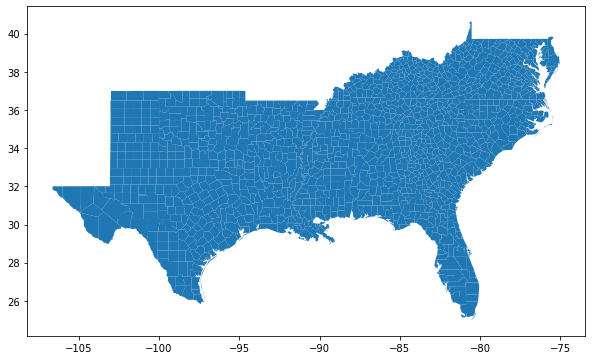

In [51]:
gdf.plot()

The map shows that the geometries `gdf` is not projected. We can confirm that by checking the Coordinate Reference System (CRS) of `gdf`.

In [54]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

It is recommanded to create a choropleth map in an equal-area projection. Next, we project the `gdf` into the Albers Equal Area Conic projection. You have done this in the previous lab. We save the projected geodataframe to `gdf2`

<AxesSubplot:>

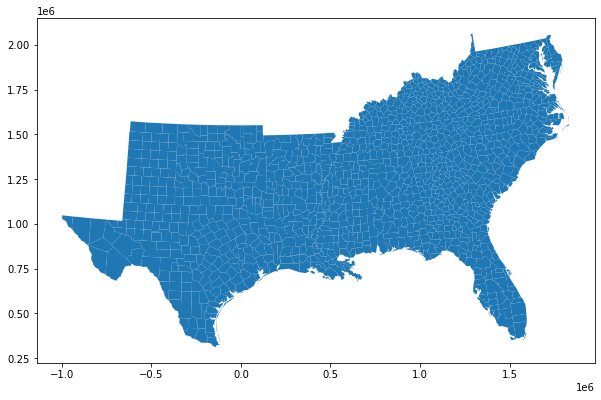

In [64]:
# Project gdf to the Albers equal area conic projection, and store the projected geodataframe in us2
gdf2 = gdf.to_crs(5070)

# plot gdf2
gdf2.plot()

Now the map has been projected to the Albers Equal Area Conic projection.

Adding a background map can show the spatial location and extent of the geometries. Next, we use use the `contextily` library to add base map to the map.

You can learn more about the `add_basemap` function from [here](https://contextily.readthedocs.io/en/latest/reference.html#plotting-basemaps).

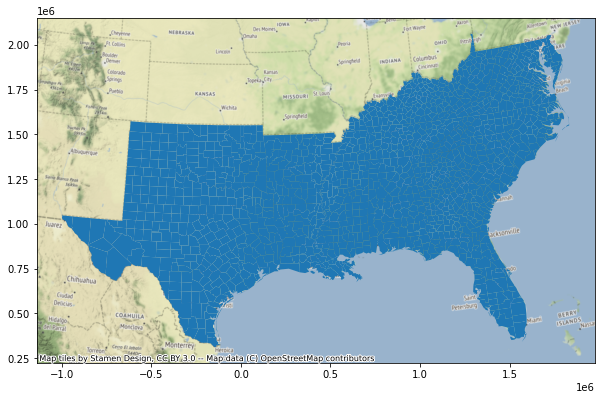

In [73]:
# First import
import contextily as cx

# plot gdf2, and save the plot in a canvas "ax"
ax = gdf2.plot()

# Adding a basemap to the canvas, also project the basemap in the projection of gdf2
cx.add_basemap(ax,crs=gdf2.crs)

In addition to the default base map, you can choose basemap from a number of basemap tile providers.

In [74]:
# Print all basemap providers
cx.providers

{'OpenStreetMap': {'Mapnik': {'url': 'https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png',
   'max_zoom': 19,
   'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
   'attribution': '(C) OpenStreetMap contributors',
   'name': 'OpenStreetMap.Mapnik'},
  'DE': {'url': 'https://{s}.tile.openstreetmap.de/tiles/osmde/{z}/{x}/{y}.png',
   'max_zoom': 18,
   'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
   'attribution': '(C) OpenStreetMap contributors',
   'name': 'OpenStreetMap.DE'},
  'CH': {'url': 'https://tile.osm.ch/switzerland/{z}/{x}/{y}.png',
   'max_zoom': 18,
   'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
   'attribution': '(C) OpenStreetMap contributors',
   'bounds': [[45, 5], [48, 11]],
   'name': 'OpenStreetMap.CH'},
  'France': {'url': 'https://{s}.tile.openstreetmap.fr/osmfr/{z}/{x}/{y}.png',
   'max_zoom': 20,
   'html_attribution': '&copy; OpenStreetMap France | &copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
   'attribution': '(C) OpenStreetMap France | (C) OpenStreetMap contributors',
   'name': 'OpenStreetMap.France'},
  'HOT': {'url': 'https://{s}.tile.openstreetmap.fr/hot/{z}/{x}/{y}.png',
   'max_zoom': 19,
   'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors, Tiles style by <a href="https://www.hotosm.org/" target="_blank">Humanitarian OpenStreetMap Team</a> hosted by <a href="https://openstreetmap.fr/" target="_blank">OpenStreetMap France</a>',
   'attribution': '(C) OpenStreetMap contributors, Tiles style by Humanitarian OpenStreetMap Team hosted by OpenStreetMap France',
   'name': 'OpenStreetMap.HOT'},
  'BZH': {'url': 'https://tile.openstreetmap.bzh/br/{z}/{x}/{y}.png',
   'max_zoom': 19,
   'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors, Tiles courtesy of <a href="http://www.openstreetmap.bzh/" target="_blank">Breton OpenStreetMap Team</a>',
   'attribution': '(C) OpenStreetMap contributors, Tiles courtesy of Breton OpenStreetMap Team',
   'bounds': [[46.2, -5.5], [50, 0.7]],
   'name': 'OpenStreetMap.BZH'},
  'BlackAndWhite': {'url': 'http://{s}.tiles.wmflabs.org/bw-mapnik/{z}/{x}/{y}.png',
   'max_zoom': 18,
   'attribution': '(C) OpenStreetMap contributors',
   'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
   'name': 'OpenStreetMap.BlackAndWhite'}},
 'OpenSeaMap': {'url': 'https://tiles.openseamap.org/seamark/{z}/{x}/{y}.png',
  'html_attribution': 'Map data: &copy; <a href="http://www.openseamap.org">OpenSeaMap</a> contributors',
  'attribution': 'Map data: (C) OpenSeaMap contributors',
  'name': 'OpenSeaMap'},
 'OPNVKarte': {'url': 'https://tileserver.memomaps.de/tilegen/{z}/{x}/{y}.png',
  'max_zoom': 18,
  'html_attribution': 'Map <a href="https://memomaps.de/">memomaps.de</a> <a href="http://creativecommons.org/licenses/by-sa/2.0/">CC-BY-SA</a>, map data &copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
  'attribution': 'Map memomaps.de CC-BY-SA, map data (C) OpenStreetMap contributors',
  'name': 'OPNVKarte'},
 'OpenTopoMap': {'url': 'https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png',
  'max_zoom': 17,
  'html_attribution': 'Map data: &copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors, <a href="http://viewfinderpanoramas.org">SRTM</a> | Map style: &copy; <a href="https://opentopomap.org">OpenTopoMap</a> (<a href="https://creativecommons.org/licenses/by-sa/3.0/">CC-BY-SA</a>)',
  'attribution': 'Map data: (C) OpenStreetMap contributors, SRTM | Map style: (C) OpenTopoMap (CC-BY-SA)',
  'name': 'OpenTopoMap'},
 'OpenRailwayMap': {'url': 'https://{s}.tiles.openrailwaymap.org/standard/{z}/{x}/{y}.png',
  'max_

Use the OpenTopMap as the basemap.

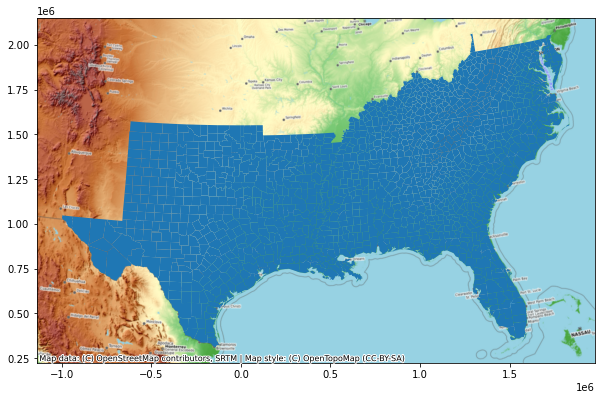

In [75]:
# First import
import contextily as cx

# plot gdf2, and save the plot in a canvas "ax"
ax = gdf2.plot()

# Adding a basemap to the canvas.
cx.add_basemap(ax,source = cx.providers.OpenTopoMap, crs=gdf2.crs)

# 4. Examing Attributes in Histogram

As shown in the above table, the HR90 column stores homicide rate per 100,000 population in 1990. Next, we will create a histogram to examine the distribution of the variable.

<AxesSubplot:>

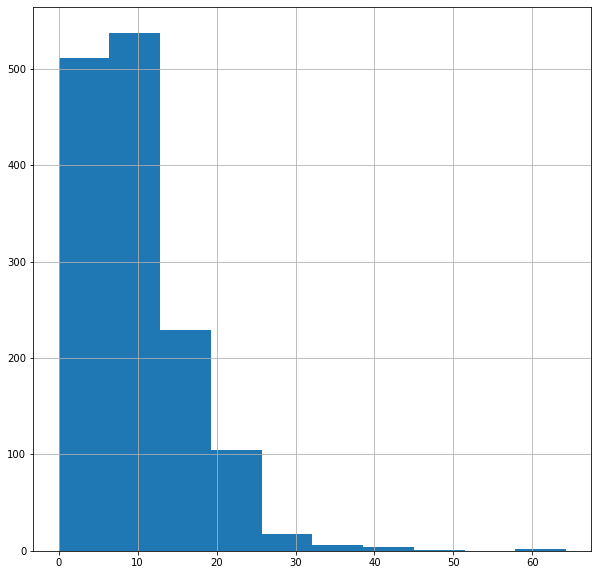

In [47]:
# Create a histogram using the "HR90" column
gdf['HR90'].hist()

The `hist()` function defaultly creates a histogram with 10 bins. But you can specify the number of bins to see the distribution in a finer granularity.

<AxesSubplot:>

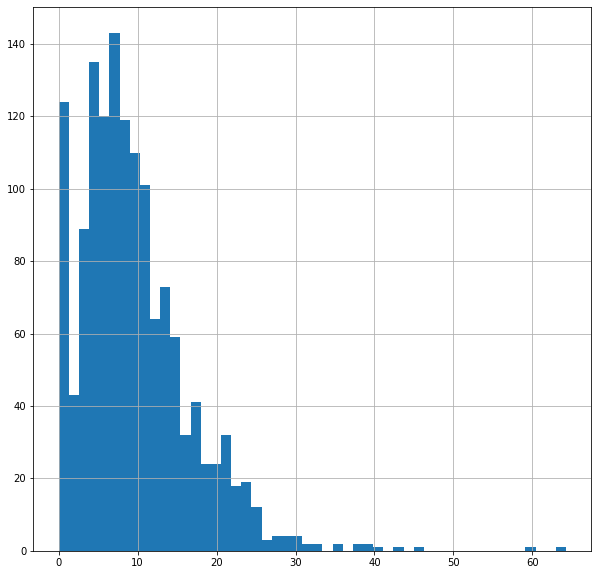

In [50]:
# Create a histogram using the "HR90" column
gdf['HR90'].hist(bins=50)

The histogram shows that the distribution of homicide rate is skewed to the left (low values). The highest frequency (highest bar) appears between 5 and 10. 